In [55]:
# importing required packages
import requests
from bs4 import BeautifulSoup as bs
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
# setting up fetch function
# help from Github Copilot
def get_web_page(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        print(f"Successfully fetched: {url}")
        return response.text
    else:
        print(f"Error {response.status_code} fetching: {url}")
        return None

In [58]:
# extracting the team statistics
def get_team_stats(soup):
    team_list = []
    
    for row in soup.find_all('tr', class_='team'):
        team = {
            'Team': row.find('td', class_='name').text.strip(),
            'Year': row.find('td', class_='year').text.strip(),
            'Wins': row.find('td', class_='wins').text.strip(),
            'Losses': row.find('td', class_='losses').text.strip(),
            'OT Losses': row.find('td', class_='ot-losses').text.strip(),
            'Win Pct': row.find('td', class_='pct').text.strip(),
            'Goals For': row.find('td', class_='gf').text.strip(),
            'Goals Against': row.find('td', class_='ga').text.strip(),
            'Diff': row.find('td', class_='diff').text.strip()
        }
        team_list.append(team)
    
    return team_list

In [59]:
# scraping 5 pages for 5 seasons of NHL data
pages = [1, 2, 3, 4, 5]
base_url = 'https://www.scrapethissite.com/pages/forms/?page_num={}'

all_teams = []

for page_num in pages:
    url = base_url.format(page_num)
    page = get_web_page(url)
    # help from Github Copilot
    if page:
        soup = bs(page, 'html.parser')
        teams = get_team_stats(soup)
        all_teams.extend(teams)
        print(f"  -> Scraped {len(teams)} rows from page {page_num}")
    
    time.sleep(3)

print(f"\nTotal rows scraped: {len(all_teams)}")

Successfully fetched: https://www.scrapethissite.com/pages/forms/?page_num=1
  -> Scraped 25 rows from page 1
Successfully fetched: https://www.scrapethissite.com/pages/forms/?page_num=2
  -> Scraped 25 rows from page 2
Successfully fetched: https://www.scrapethissite.com/pages/forms/?page_num=3
  -> Scraped 25 rows from page 3
Successfully fetched: https://www.scrapethissite.com/pages/forms/?page_num=4
  -> Scraped 25 rows from page 4
Successfully fetched: https://www.scrapethissite.com/pages/forms/?page_num=5
  -> Scraped 25 rows from page 5

Total rows scraped: 125


In [44]:
# creating a dataframe
df = pd.DataFrame(all_teams)
print(df.shape)
df.head()

(125, 9)


,Team,Year,Wins,Losses,OT Losses,Win Pct,Goals For,Goals Against,Diff
0,Boston Bruins,1990,44,24,,0.55,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,,0.425,273,298,-25


In [45]:
# converting numeric columns
numeric_cols = ['Wins', 'Losses', 'OT Losses', 'Win Pct', 'Goals For', 'Goals Against', 'Diff']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# converting year to integer
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# dropping rows with nan
df = df.dropna(subset=['Wins']).reset_index(drop=True)

# printing data
print(f"Cleaned DF shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head()

Cleaned DF shape: (125, 9)
Missing values:
Team               0
Year               0
Wins               0
Losses             0
OT Losses        125
Win Pct            0
Goals For          0
Goals Against      0
Diff               0
dtype: int64


,Team,Year,Wins,Losses,OT Losses,Win Pct,Goals For,Goals Against,Diff
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


In [46]:
# Question 1: What was the average win percentage across all teams each year?
avg_pct = df.groupby('Year')['Win Pct'].mean().round(4)
print("Average Win Percentage by Year:")
print(avg_pct)

Average Win Percentage by Year:
Year
1990    0.4334
1991    0.4335
1992    0.4505
1993    0.4360
1994    0.4398
1995    0.4655
Name: Win Pct, dtype: float64


**Conclusion:** The average win percentage stays near 0.50 each year, which makes sense, since every win produces a corresponding loss.

Average Goals For by Year:
Year
1990    276.43
1991    278.32
1992    304.62
1993    272.35
1994    143.35
1995    267.17
Name: Goals For, dtype: float64


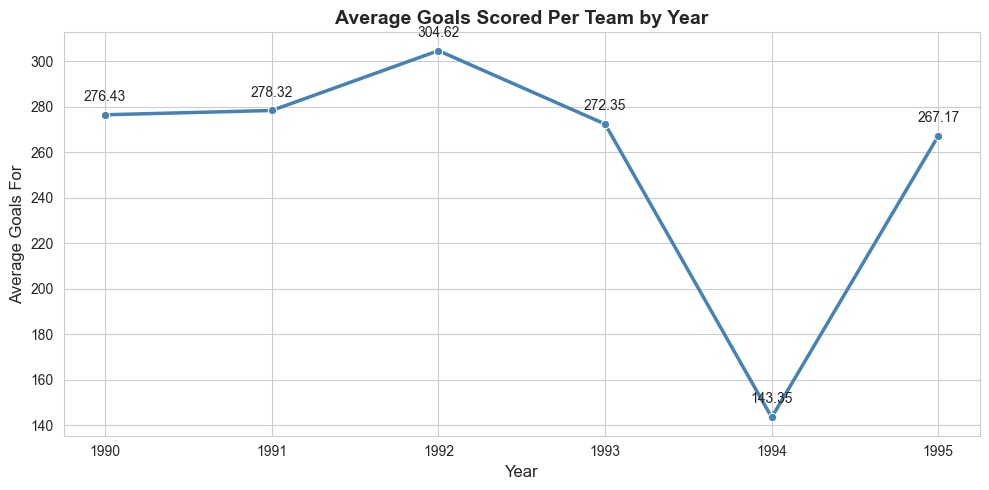

In [47]:
# Question 2: Which year had the highest average goals scored?
# help from Github Copilot
avg_gf = df.groupby('Year')['Goals For'].mean().round(2)
print("Average Goals For by Year:")
print(avg_gf)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=avg_gf.index, y=avg_gf.values, marker='o', linewidth=2.5, color='steelblue', ax=ax)

for x, y in zip(avg_gf.index, avg_gf.values):
    ax.annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

ax.set_title('Average Goals Scored Per Team by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Goals For', fontsize=12)
plt.tight_layout()
plt.show()

**Conclusion:** The average goals scored per team fluctuated across the early 1990s, with some years seeing notably higher or lower offensive output, which is likely due to rule changes and changing team strategies.

In [48]:
# Question 3: How many teams had a winning record (win pct > 0.5) each year?
winning_teams = df[df['Win Pct'] > 0.5].groupby('Year').size()
print("Number of Teams with Winning Records by Year:")
print(winning_teams)

Number of Teams with Winning Records by Year:
Year
1990     6
1991     5
1992    10
1993     6
1994     6
1995     1
dtype: int64


**Conclusion:** The number of teams with winning records varied significantly, with 1992 having 10 teams above .500 while 1995 having only 1. The 1995 season was shortened by a lockout, which compressed the schedule and likely made it harder for teams to build improve their records.

Top 5 Teams by Wins in a Single Season:
               Team  Year  Wins
Pittsburgh Penguins  1992    56
   New York Rangers  1993    52
      Boston Bruins  1992    51
   New York Rangers  1991    50
 Chicago Blackhawks  1990    49


C:\Users\flipp\AppData\Local\Temp\ipykernel_26384\2693593901.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_wins['Wins'].values, y=labels.values, palette=palette, ax=ax)


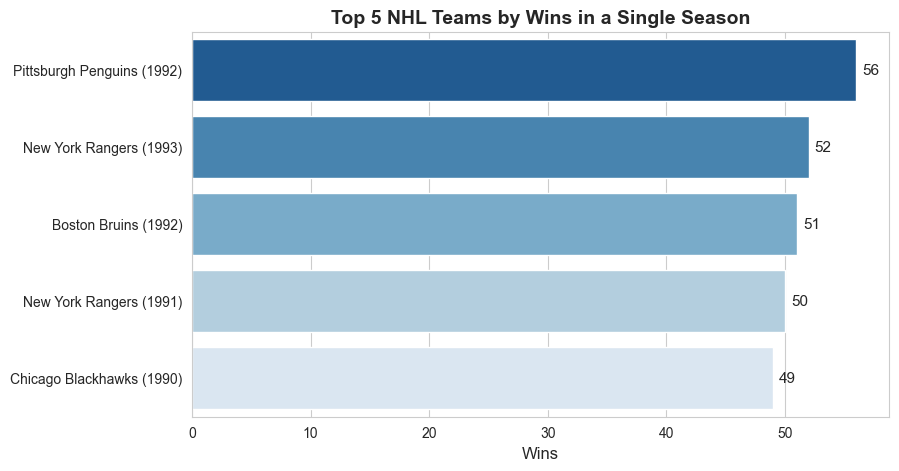

In [50]:
# Question 4: What are the top 5 teams with the most wins in a single season?
# help from Github Copilot
top_wins = df.nlargest(5, 'Wins')[['Team', 'Year', 'Wins']]
print("Top 5 Teams by Wins in a Single Season:")
print(top_wins.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
labels = top_wins['Team'] + ' (' + top_wins['Year'].astype(int).astype(str) + ')'
palette = sns.color_palette("Blues_r", n_colors=5)
sns.barplot(x=top_wins['Wins'].values, y=labels.values, palette=palette, ax=ax)

for i, val in enumerate(top_wins['Wins'].values):
    ax.text(val + 0.5, i, str(int(val)), va='center', fontsize=11)

ax.set_title('Top 5 NHL Teams by Wins in a Single Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Wins', fontsize=12)
ax.set_ylabel('')
plt.show()

**Conclusion:** The Pittsburgh Penguins in 1992 had the most wins in a single season with 56 due to 2 Stanley Cup championships in a row, while the New York Rangers appear twice in the top 5, showing they were consistently one of the highest performing teams in the early 1990s. Additionally, the rest of teams in the top 5 were before or during 1995, due to evolving game practices and rules.